In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r '/content/drive/Shareddrives/ML/PlantVillage' '/content/PlantVillage'
print("✅ Dataset siap!")

✅ Dataset siap!


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import xgboost as xgb
import joblib

DATASET_PATH    = '/content/PlantVillage'
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
SEED            = 42
CHECKPOINT_PATH = '/content/drive/Shareddrives/ML/checkpoints/'

class_names = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(class_names)
print(f"Jumlah kelas: {NUM_CLASSES}")

Jumlah kelas: 15


In [ ]:
cnn_model    = tf.keras.models.load_model(
    CHECKPOINT_PATH + 'cnn_balanced_best.keras',
    custom_objects={'preprocess_input': preprocess_input}
)
effnet_model = tf.keras.models.load_model(
    CHECKPOINT_PATH + 'effnet_phase2_balanced_best.keras',
    custom_objects={'preprocess_input': preprocess_input}
)
xgb_model    = joblib.load(CHECKPOINT_PATH + 'xgb_balanced_model.pkl')
print("semua model balanced berhasil diload!")

✅ Semua model balanced berhasil diload!


In [ ]:
eval_cnn_gen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2
).flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED
)

eval_eff_gen = ImageDataGenerator(
    validation_split=0.2
).flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED
)

print(f"Eval CNN    : {eval_cnn_gen.samples} gambar")
print(f"Eval EffNet : {eval_eff_gen.samples} gambar")

Found 4122 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Eval CNN    : 4122 gambar
Eval EffNet : 4122 gambar


In [ ]:
feature_extractor = models.Model(
    inputs=effnet_model.input,
    outputs=effnet_model.layers[-4].output
)

val_ext = ImageDataGenerator(
    validation_split=0.2
).flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED
)

print("Mengekstrak fitur val...")
X_val_feat = feature_extractor.predict(val_ext, verbose=1)
y_val_feat = val_ext.classes
print(f"Shape: {X_val_feat.shape}")

Found 4122 images belonging to 15 classes.
Mengekstrak fitur val...
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step
Shape: (4122, 1280)


In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_macro    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n{'='*50}")
    print(f"Model       : {name}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Weighted F1 : {f1_weighted:.4f}")
    print(f"Macro F1    : {f1_macro:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    return acc, f1_weighted, f1_macro

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step

Model       : CNN Balanced
Accuracy    : 0.8777
Weighted F1 : 0.8787
Macro F1    : 0.8463
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.92      0.88      0.90       199
                     Pepper__bell___healthy       0.94      0.93      0.93       295
                      Potato___Early_blight       0.79      0.96      0.87       200
                       Potato___Late_blight       0.67      0.90      0.77       200
                           Potato___healthy       0.40      0.83      0.54        30
                      Tomato_Bacterial_spot       0.98      0.89      0.94       425
                        Tomato_Early_blight       0.81      0.69      0.75       200
                         Tomato_Late_blight       0.95      0.74      0.83       381
                           Tomato_Leaf_Mold       0.85      0.92      0.88       190
               

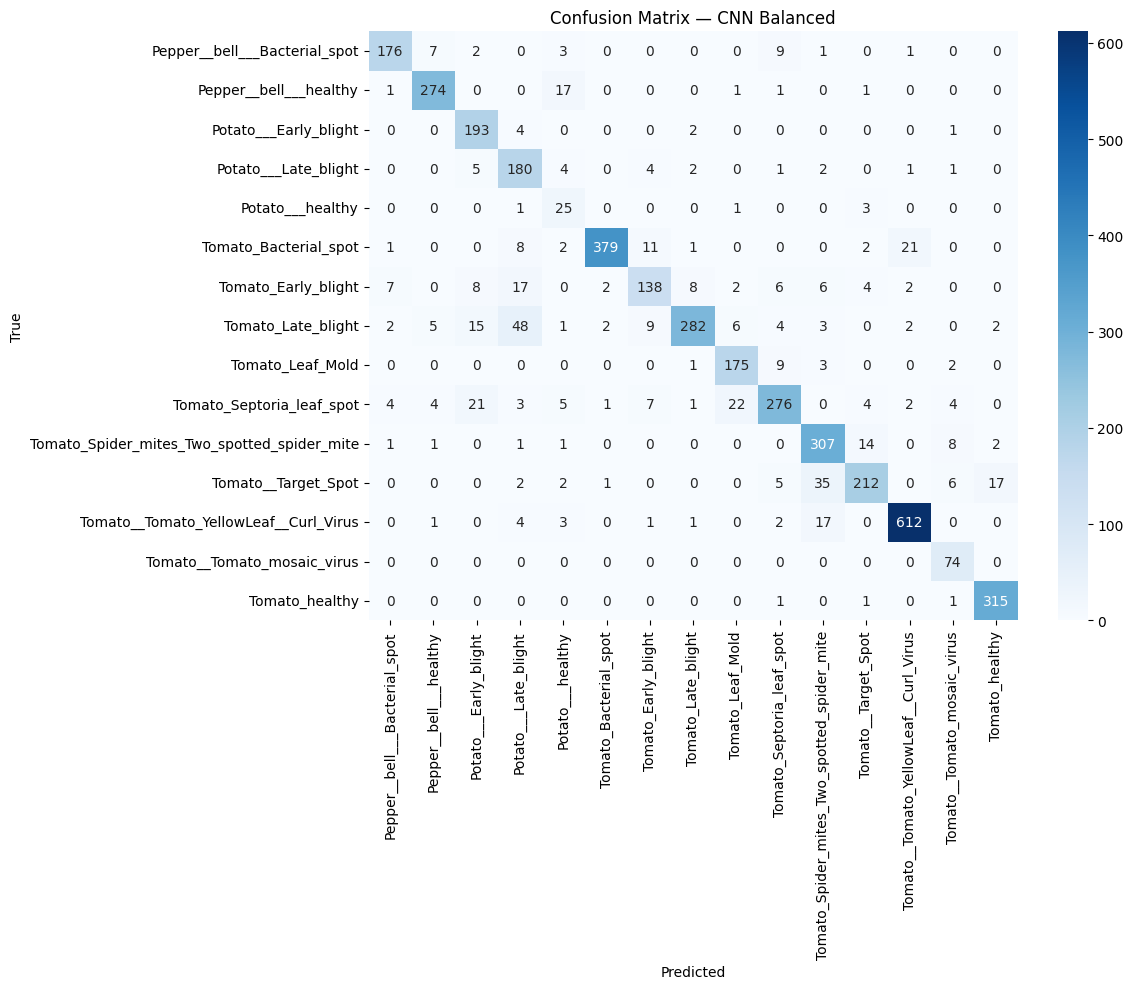

129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step

Model       : EfficientNetB0 Balanced
Accuracy    : 0.9476
Weighted F1 : 0.9481
Macro F1    : 0.9479
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.98      0.98       199
                     Pepper__bell___healthy       0.99      0.99      0.99       295
                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       0.97      0.96      0.97       200
                           Potato___healthy       0.91      1.00      0.95        30
                      Tomato_Bacterial_spot       0.98      0.92      0.95       425
                        Tomato_Early_blight       0.92      0.85      0.88       200
                         Tomato_Late_blight       0.97      0.94      0.96       381
                           Tomato_Leaf_Mold       0.96      0.98      0.97       190
   

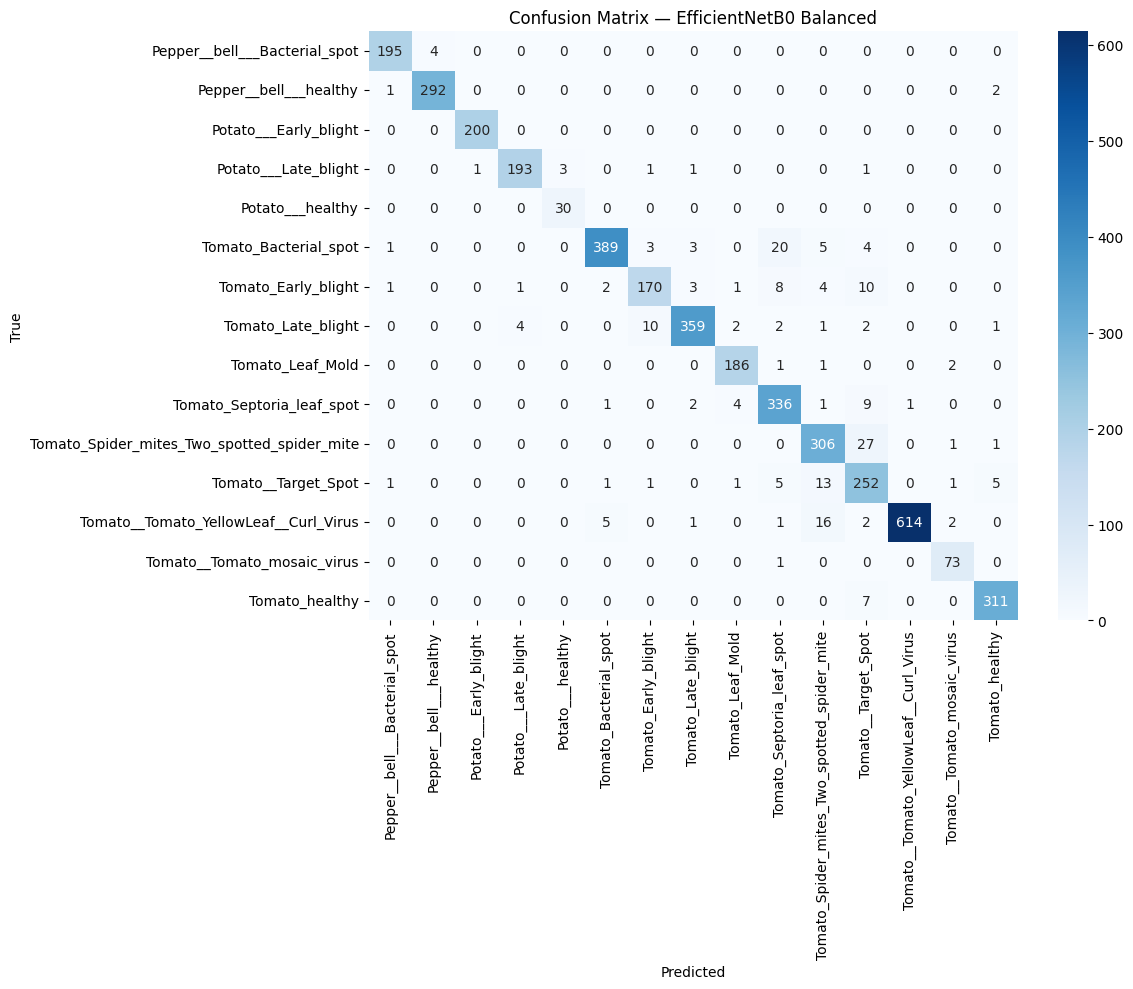


Model       : Hybrid Balanced
Accuracy    : 0.9515
Weighted F1 : 0.9514
Macro F1    : 0.9470
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.97      0.97       199
                     Pepper__bell___healthy       0.98      0.98      0.98       295
                      Potato___Early_blight       0.97      0.97      0.97       200
                       Potato___Late_blight       0.98      0.95      0.97       200
                           Potato___healthy       0.96      0.90      0.93        30
                      Tomato_Bacterial_spot       0.95      0.97      0.96       425
                        Tomato_Early_blight       0.85      0.81      0.83       200
                         Tomato_Late_blight       0.94      0.94      0.94       381
                           Tomato_Leaf_Mold       0.94      0.98      0.96       190
                  Tomato_Septoria_leaf_spot       0.95 

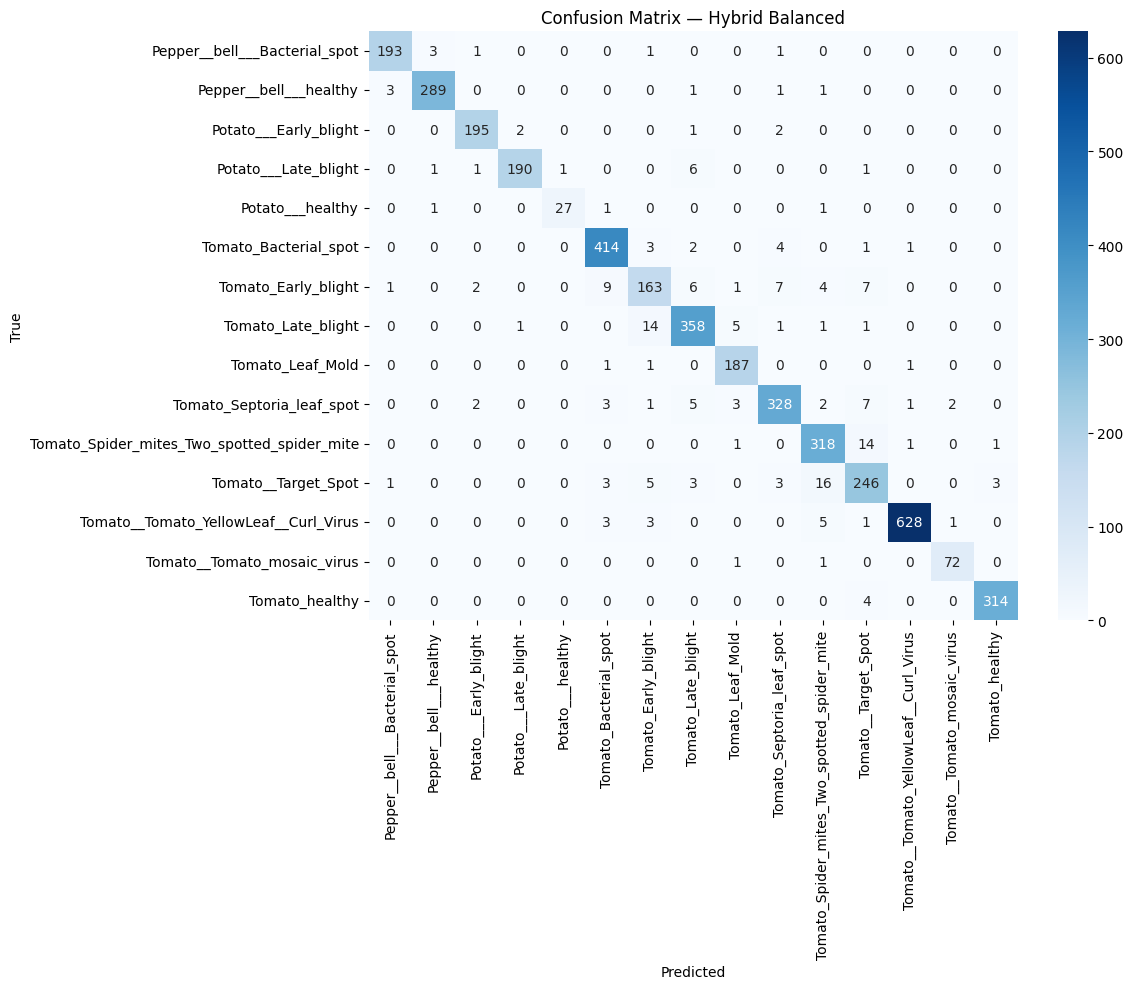

In [ ]:
y_pred_cnn = np.argmax(cnn_model.predict(eval_cnn_gen, verbose=1), axis=1)
acc_cnn, f1w_cnn, f1m_cnn = evaluate_model("CNN Balanced", eval_cnn_gen.classes, y_pred_cnn)

y_pred_eff = np.argmax(effnet_model.predict(eval_eff_gen, verbose=1), axis=1)
acc_eff, f1w_eff, f1m_eff = evaluate_model("EfficientNetB0 Balanced", eval_eff_gen.classes, y_pred_eff)

y_pred_hyb = xgb_model.predict(X_val_feat)
acc_hyb, f1w_hyb, f1m_hyb = evaluate_model("Hybrid Balanced", y_val_feat, y_pred_hyb)

                  Model  Accuracy  Weighted F1  Macro F1
        Hybrid Balanced  0.951480     0.951418  0.947048
EfficientNetB0 Balanced  0.947598     0.948096  0.947874
           CNN Balanced  0.877729     0.878741  0.846252


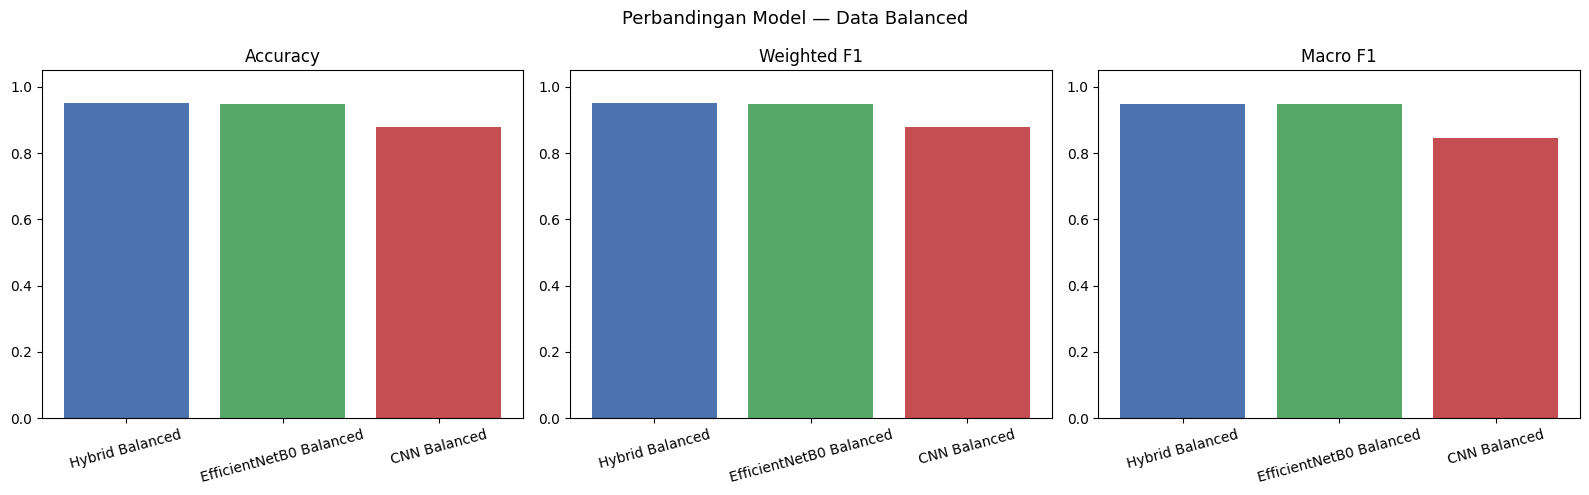

In [ ]:
results = pd.DataFrame({
    'Model'       : ['CNN Balanced', 'EfficientNetB0 Balanced', 'Hybrid Balanced'],
    'Accuracy'    : [acc_cnn, acc_eff, acc_hyb],
    'Weighted F1' : [f1w_cnn, f1w_eff, f1w_hyb],
    'Macro F1'    : [f1m_cnn, f1m_eff, f1m_hyb]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(results['Model'], results['Accuracy'], color=colors)
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title('Accuracy')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Model'], results['Weighted F1'], color=colors)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title('Weighted F1')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results['Model'], results['Macro F1'], color=colors)
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title('Macro F1')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Perbandingan Model — Data Balanced', fontsize=13)
plt.tight_layout()
plt.show()

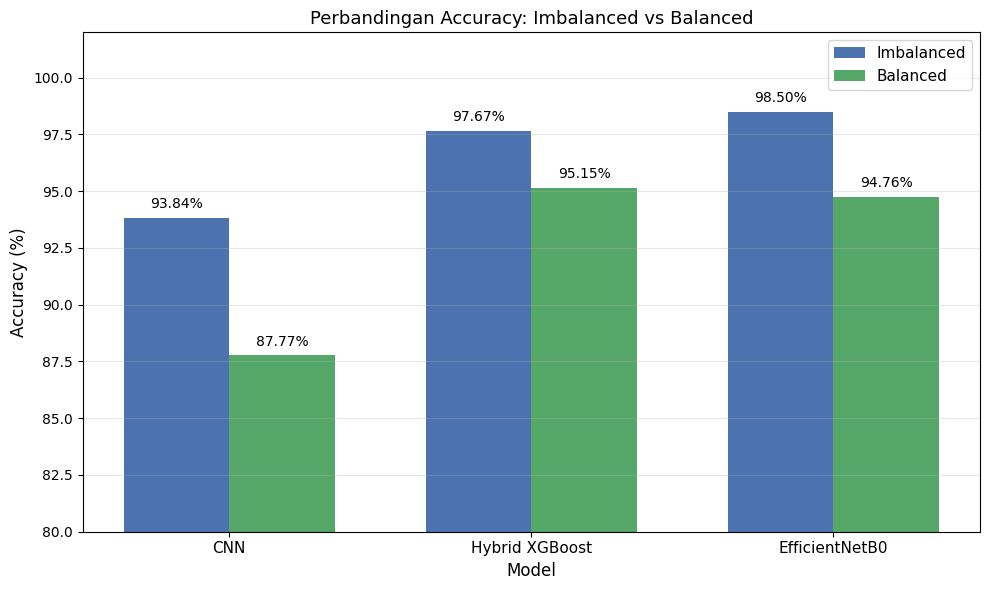

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['CNN', 'Hybrid XGBoost', 'EfficientNetB0']
imbalanced = [93.84, 97.67, 98.50]
balanced   = [87.77, 95.15, 94.76]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, imbalanced, width, label='Imbalanced', color='#4C72B0')
bars2 = ax.bar(x + width/2, balanced,   width, label='Balanced',   color='#55A868')

# Tambah nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Perbandingan Accuracy: Imbalanced vs Balanced', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(80, 102)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()